In [1]:
import pandas as pd
import re
import json
import random
import os
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud
import seaborn as sns
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import uuid

In [2]:
food_dir='dataset/gofood_dataset.csv'
names_dir = 'dataset/indonesian-names.csv'
makanan_dir = 'dataset/alergen_dataset.csv'
menu_dir = 'dataset/Steakhouse_dataset.csv'
nutrition_dir = 'dataset/nutrition.csv'
indo_food_dir = 'dataset/indonesian_food.csv'


In [3]:
df_food = pd.read_csv(food_dir)
df_names = pd.read_csv(names_dir)
df_alergen = pd.read_csv(makanan_dir)
df_steakhouse = pd.read_csv(menu_dir, sep=';', on_bad_lines='skip')
df_indofood = pd.read_csv(indo_food_dir)
df_nutri = pd.read_csv(nutrition_dir)

## EDAs

### Plot Distribution

In [4]:
# drop nans
datasets = {
    "GoFood": df_food['product'].dropna().astype(str),
    "Allergen": df_alergen['Product'].dropna().astype(str),
    "Steakhouse": df_steakhouse['unique_menu'].dropna().astype(str),
    "Indo_Food": df_indofood['Nama'].dropna().astype(str),
    "Nutrition": df_nutri['name'].dropna().astype(str),
}

In [5]:
def calculate_word_counts(series):
    return series.apply(lambda x: len(x.split()))

def contains_promo_words(text):
    promo_pattern = r'\b(promo|gratis|free|diskon|murah|jual|paket|grosir)\b'
    return bool(re.search(promo_pattern, text.lower()))

def contains_noise_chars(text):
    noise_pattern = r'[\(\)\[\]\-\|]|\b\d+(gr|gram|kg|ml|liter|pcs)\b'
    return bool(re.search(noise_pattern, text.lower()))


[GoFood] - Total Items: 45,195
  Avg Word Count: 3.2 words
  Contains Promo/SEO Words: 2.9%
  Contains Brackets/Units/Dashes: 8.6%

[Allergen] - Total Items: 100,000
  Avg Word Count: 3.1 words
  Contains Promo/SEO Words: 0.0%
  Contains Brackets/Units/Dashes: 0.0%

[Steakhouse] - Total Items: 150
  Avg Word Count: 3.6 words
  Contains Promo/SEO Words: 0.7%
  Contains Brackets/Units/Dashes: 22.0%

[Indo_Food] - Total Items: 1,273
  Avg Word Count: 2.6 words
  Contains Promo/SEO Words: 0.0%
  Contains Brackets/Units/Dashes: 5.1%

[Nutrition] - Total Items: 1,346
  Avg Word Count: 2.6 words
  Contains Promo/SEO Words: 0.0%
  Contains Brackets/Units/Dashes: 5.4%


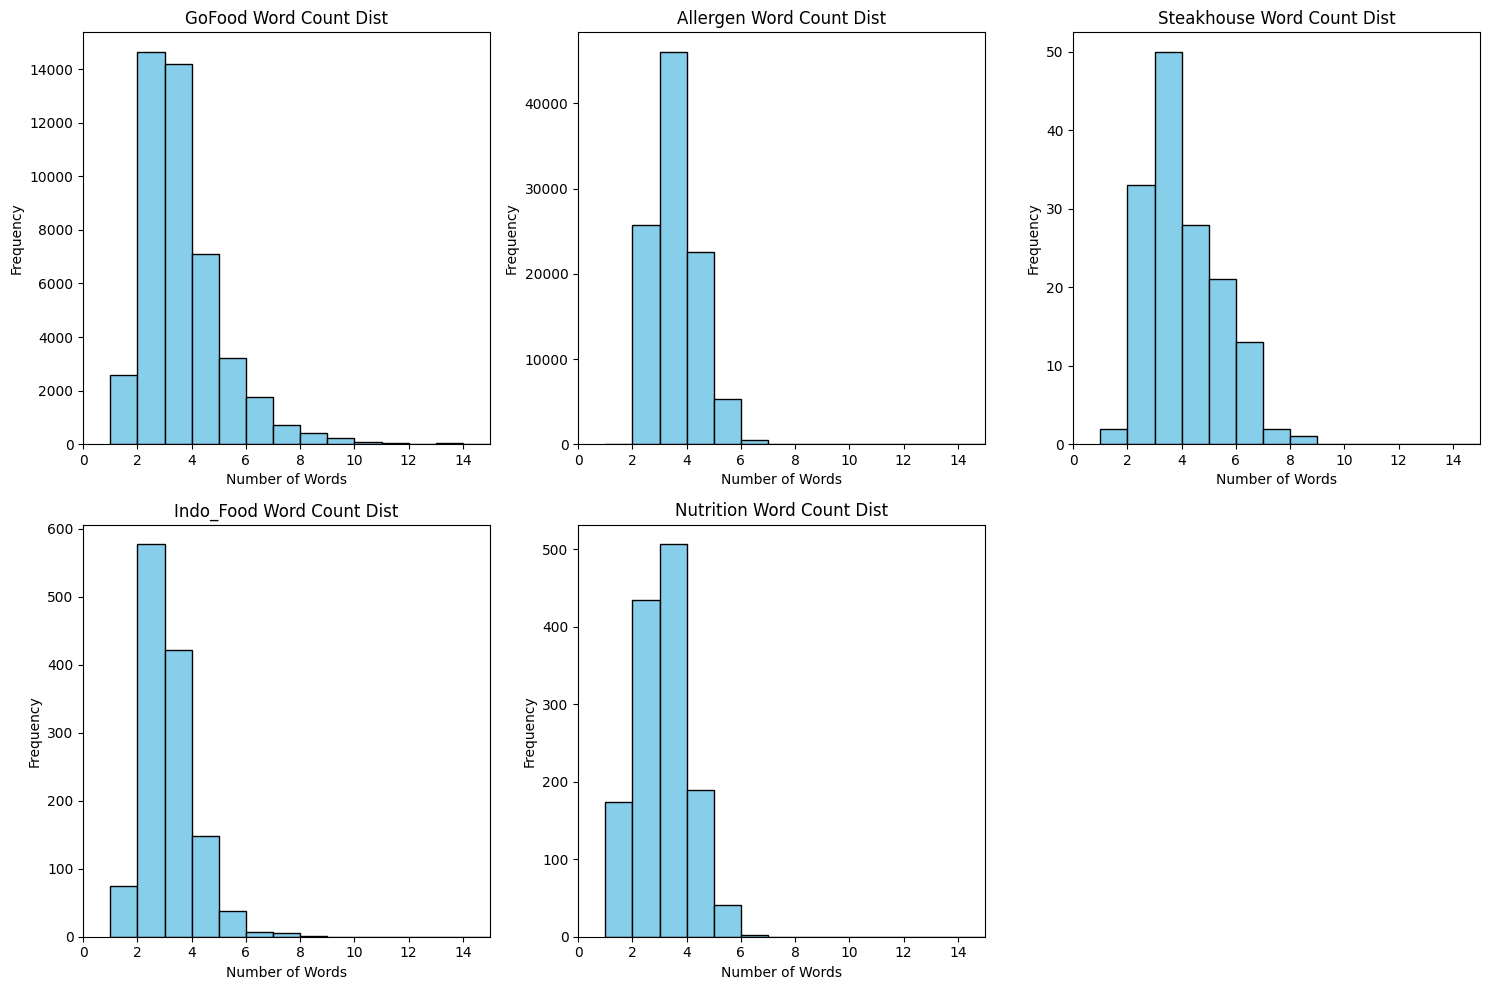

In [6]:
plt.figure(figsize=(15, 10))

for i, (name, series) in enumerate(datasets.items(), 1):
    word_counts = calculate_word_counts(series)
    avg_words = word_counts.mean()
    promo_pct = series.apply(contains_promo_words).mean() * 100
    noise_pct = series.apply(contains_noise_chars).mean() * 100
    
    print(f"\n[{name}] - Total Items: {len(series):,}")
    print(f"  Avg Word Count: {avg_words:.1f} words")
    print(f"  Contains Promo/SEO Words: {promo_pct:.1f}%")
    print(f"  Contains Brackets/Units/Dashes: {noise_pct:.1f}%")
    
    plt.subplot(2, 3, i)
    plt.hist(word_counts, bins=range(1, 20), color='skyblue', edgecolor='black')
    plt.title(f'{name} Word Count Dist')
    plt.xlabel('Number of Words')
    plt.ylabel('Frequency')
    plt.xlim(0, 15)

plt.tight_layout()
plt.show()

### Bigram/Trigram Frequencies

In [7]:
def get_top_ngrams(series, n=2, top_k=10):
    ngrams = []
    for text in series:
        words = str(text).lower().split()
        if len(words) >= n:
            for i in range(len(words) - n + 1):
                ngrams.append(" ".join(words[i:i+n]))
    return Counter(ngrams).most_common(top_k)

for ngram, count in get_top_ngrams(datasets["GoFood"], n=2):
    print(f"  {ngram}: {count}")

  nasi goreng: 586
  milk tea: 343
  kopi susu: 335
  red velvet: 291
  brown sugar: 280
  es kopi: 265
  green tea: 241
  french fries: 233
  lemon tea: 223
  chicken burger: 223


### price distribution of steakhouse

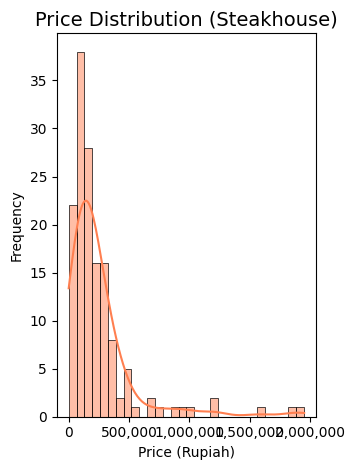

In [8]:
plt.subplot(1, 2, 2)
if 'price' in df_steakhouse.columns:
    clean_prices = df_steakhouse['price'].astype(str).str.replace(r'[^\d]', '', regex=True)
    clean_prices = pd.to_numeric(clean_prices[clean_prices != ''], errors='coerce').dropna()
    
    sns.histplot(clean_prices, bins=30, kde=True, color='coral')
    plt.title('Price Distribution (Steakhouse)', fontsize=14)
    plt.xlabel('Price (Rupiah)')
    plt.ylabel('Frequency')
    plt.gca().xaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))
else:
    plt.text(0.5, 0.5, 'Price column not found', ha='center', va='center')

plt.tight_layout()
plt.show()

## Cleaning

### food & prod dataset cleaning

In [9]:
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

In [10]:
extra_stopwords = ['warna', 'ukuran', 'rasa', 'level', 'isi', 'pcs']

In [11]:
def extract_core_item(text: str) -> str:
    """
    Cleans noisy e-commerce titles and clinical nutrition names 
    to extract a conversational 1-3 word item name.
    """
    if not isinstance(text, str) or pd.isna(text):
        return ""
    
    text = text.lower().strip()
    
    text = re.sub(r'\(.*?\)|\[.*?\]|\{.*?\}', '', text)
    
    split_pattern = r'\b(dengan|rasa|level|topping|extra|ekstra|isi|pakai|ala|varian|ukuran)\b|\+|&'
    text = re.split(split_pattern, text)[0]
    
    units_pattern = r'\b\d+[\s,-]*(gr|gram|kg|ml|liter|pcs|biji|porsi|x|cup|bowl|box|pack|slice|potong)\b'
    text = re.sub(units_pattern, '', text)
    text = re.sub(r'\b(jumbo|reguler|medium|large|small|besar|kecil)\b', '', text)
    
    promo_words = r'\b(promo|gratis|free|diskon|murah|jual|paket|hemat|spesial|special|bonus|ongkir|ori|original|termurah|garansi|cod|ready|stock|baru|new)\b'
    text = re.sub(promo_words, '', text)
    
    text = re.sub(r'\d+', '', text)
    
    text = stopword_remover.remove(text)
    
    nutrition_stopwords = ['segar', 'mentah', 'masakan', 'bubuk', 'kering', 'basah']
    for word in nutrition_stopwords:
        text = re.sub(rf'\b{word}\b', '', text)
        
    extra_stopwords = ['warna', 'pilihan', 'menu', 'dan']
    for word in extra_stopwords:
        text = re.sub(rf'\b{word}\b', '', text)
    
    text = re.split(r'[-|/]', text)[0]
    
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    words = [w for w in text.split() if len(w) > 1]
    
    return " ".join(words[:3]).strip()

In [12]:
# extra items
TRANSPORT_ITEMS = [
    # Ride hailing
    "grabcar", "gojek", "gocar", "grabbike", "ojek online", "taksi",
    "grab", "maxim", "indriver",
    # Tickets
    "tiket bioskop", "tiket konser", "tiket kereta", "tiket pesawat",
    "tiket masuk", "tiket wahana", "tiket kapal",
    # Toll / parking
    "tol", "parkir", "e-toll", "tiket parkir",
    # Public transport
    "busway", "mrt", "lrt", "krl", "transjakarta", "angkot",
    # Household basics
    "sabun", "shampo", "odol", "pasta gigi", "tisu", "deterjen",
    "minyak goreng", "gula", "beras", "telur", "gas",
    # Common shared bills
    "bensin", "bahan bakar", "pertalite", "pertamax",
    "listrik", "air", "wifi", "iuran",
]

In [13]:
all_clean_items = pd.concat([
    datasets["GoFood"].apply(extract_core_item),
    datasets["Allergen"].apply(extract_core_item),
    datasets["Steakhouse"].apply(extract_core_item),
    datasets['Indo_Food'].apply(extract_core_item),
    datasets['Nutrition'].apply(extract_core_item),
    pd.Series(TRANSPORT_ITEMS)
])

unique_items = all_clean_items[all_clean_items != ""].drop_duplicates().tolist()
print(f"Total unique items for augmentation: {len(unique_items)}")

Total unique items for augmentation: 20445


In [14]:
trash_items = {'t', 'a', 'the', 'of', 'set', 'an', 'is', '1', '2', '3'}

final_items = [
    item for item in unique_items 
    if len(item) > 1 and item not in trash_items and not item.isdigit()
]

In [15]:
len(final_items)

20443

In [16]:
final_items[10000:10500]

['kacang caramel',
 'kue pia',
 'lemon cheese',
 'marmer oval',
 'pastry cake',
 'pastry coklat',
 'pastry molen',
 'pisang keju petak',
 'redvelvet glng',
 'redvelvet tarcis segi',
 'roti gembung',
 'spekuk bulat',
 'spong kacang hijau',
 'sus manis',
 'swiis roll art',
 'tawar',
 'tawar cake biasa',
 'tawar sorek kosong',
 'zeefin vanilla moist',
 'zeefine choco moist',
 'ziffone vanilla',
 'bolu blacksy cake',
 'bolu nenas',
 'cake pisang coklat',
 'donat',
 'double coklat',
 'marmer cake bulat',
 'orange cake',
 'pisang caramel bulat',
 'pisang caramel panjang',
 'roti manis kosong',
 'spong blackforest',
 'spong coconut cake',
 'spong pandan bulat',
 'spong mocca',
 'spong pandan petak',
 'tawar kentang',
 'tawar kismis',
 'tawar pandan',
 'tawar wortel',
 'brownies kukus mini',
 'cake pisang mini',
 'sate taichan ayam',
 'sate taichan kulit',
 'ceker bakar taichan',
 'taichan mix',
 'sosis bakar taichan',
 'telur gulung taichan',
 'indomie goreng taichan',
 'porsi kenyang',
 'tai

### wordcloud visualisation

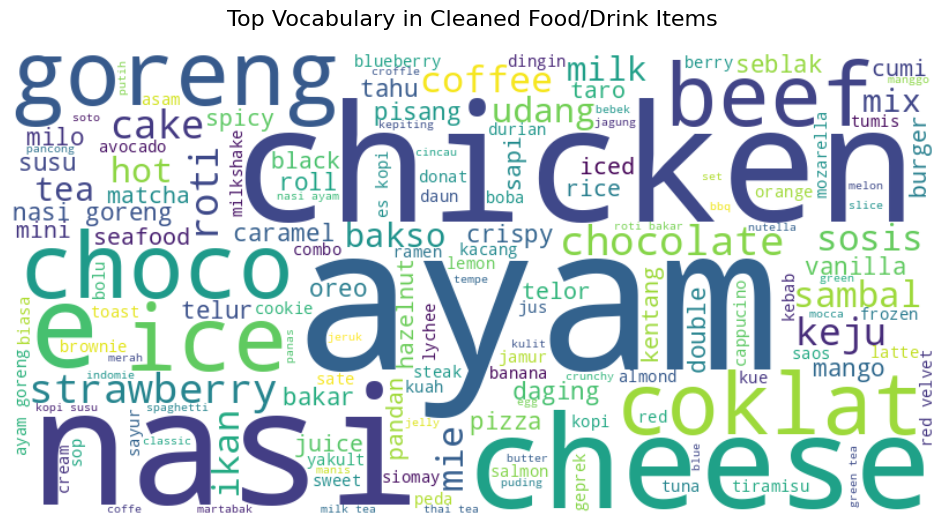

In [17]:
text_for_cloud = " ".join(final_items)

wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='white', 
    colormap='viridis',
    max_words=150
).generate(text_for_cloud)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Top Vocabulary in Cleaned Food/Drink Items', fontsize=16, pad=20)
plt.show()

### names cleaning

In [18]:
df_names['name'].sort_values()

430              a. solikhin
1304              aam aminah
6                aan nuraini
494             abas suyatno
1260    abdi ahmad permadani
                ...         
77                  zubaidah
1488                zubaidah
112           zukri adinalta
149             zukri rahman
909      zulvan arfa syazwan
Name: name, Length: 1960, dtype: str

In [19]:
def extract_first_name(name_list):
    cleaned = []
    
    title_pattern = r'^(a\.?\s*|hj\.?\s*|h\.?\s*|drs\.?\s*|dr\.?\s*|ir\.?\s*|prof\.?\s*|kh\.?\s*|ust\.?\s*|ustadz\.?\s*|st\.?\s*|se\.?\s*)'
    
    for name in name_list:
        n = str(name).lower().strip()
        
        n = re.sub(title_pattern, '', n, flags=re.IGNORECASE).strip()
        
        parts = n.split()
        if not parts:
            continue
            
        first = parts[0]
        
        if len(first) < 3:
            continue
            
        cleaned.append(first.capitalize())
    
    return sorted(list(set(cleaned)))

In [20]:
indo_names = extract_first_name(df_names['name'])
print(f"Total unique casual names: {len(indo_names)}")
print(f"Sample: {random.sample(indo_names, 15)}")

Total unique casual names: 1266
Sample: ['Makruf', 'Rahma', 'Sitti', 'Lamet', 'Thamrin', 'Yusrika', 'Sofyan', 'Nafis', 'Nony', 'Turhadi', 'Nazwa', 'Tian', 'Ikhwan', 'Sholekhan', 'Nofan']


In [21]:
with open('dataset/names.json', 'r') as file:
    extra_names = json.load(file)

In [22]:
print(len(extra_names))
print(f"Sample: {random.sample(extra_names, 20)}")

1931
Sample: ['Nana', 'Marco', 'Marolop', 'Lydia', 'Unis', 'Lukman', 'Jenny', 'Satrios', 'Celline', 'Untos', 'Rennie', 'Ursulla', 'Sahat', 'Claray', 'Kresna', 'Maulida', 'Lithy', 'Hotmaida', 'Helenna', 'Felline']


In [23]:
def merge_name_datasets(indonesian_names, additional_names=None):
    all_names = set(indonesian_names)
    all_names.update(extra_names)
    
    if additional_names:
        all_names.update(additional_names)
    
    final = []
    for name in all_names:
        n = name.strip().capitalize()
        if len(n) >= 3 and n.isalpha():
            final.append(n)
    
    return sorted(list(set(final)))

EXTERNAL_NAMES = merge_name_datasets(indo_names)
print(f"Total names: {len(EXTERNAL_NAMES)}")
print(f"Sample: {random.sample(EXTERNAL_NAMES, 15)}")

Total names: 3076
Sample: ['Wagimun', 'Jako', 'Kevin', 'Mappasere', 'Noldy', 'Queeny', 'Muhaimin', 'Taufiky', 'Ramlan', 'Emils', 'Saris', 'Ingride', 'Ibnu', 'Ngatini', 'Ginay']


### generate prices

In [24]:
def generate_random_price():
    """
    Generates realistic Indonesian price expressions covering:
    - Slang / street terms (seceng, goceng, etc.)
    - Abbreviated formats (50k, 50rb, 50ribu)
    - Formal formats (Rp 50.000, Rp50.000,-)
    - Typo/casual variants (50K, 50RB, rp50k)
    - Million formats (1jt, 1.5jt)
    - Fraction slang (setengah ceban, dua setengah)
    - Per-person split hints (50k/orang, 25k/kepala)
    """
    slang_map = {
        500:    ["gopek", "limapek"],
        1000:   ["seceng", "seribu", "saceng"],
        1500:   ["cenggo", "senggo"],
        2000:   ["noceng", "dua ceng"],
        2500:   ["nocenggo"],
        5000:   ["goceng", "gocen", "lima rebu"],
        7500:   ["tujuh setengah"],
        10000:  ["ceban", "seceban", "satu ceban", "sepuluh rebu"],
        15000:  ["ceban setengah", "lima belas rebu"],
        20000:  ["noban", "dua ceban", "duapu rebu"],
        25000:  ["noban setengah", "dua puluh lima rebu"],
        50000:  ["gocap", "lima puluh rebu", "setengah cepek"],
        75000:  ["tujuh puluh lima rebu"],
        100000: ["cepek", "satu cepek", "seratus rebu"],
        150000: ["cepek setengah"],
        200000: ["dua cepek", "dua ratus rebu"],
        500000: ["lima cepek", "setengah juta"],
    }

    if random.random() < 0.20:
        chosen_value = random.choice(list(slang_map.keys()))
        return random.choice(slang_map[chosen_value])

    if random.random() < 0.07:
        jt_val = random.choice([
            1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5,
            1.2, 1.8, 2.2, 2.8
        ])
        jt_formats = [
            f"{jt_val}jt",
            f"{jt_val} jt",
            f"{jt_val}juta",
            f"{jt_val} juta",
            f"Rp {jt_val}jt",
            f"Rp{jt_val}jt",
            f"Rp {jt_val} juta",
            f"{jt_val}J",
            f"{jt_val} J",
        ]
        return random.choice(jt_formats)

    if random.random() < 0.08:
        val = random.choice([10, 15, 20, 25, 30, 35, 40, 45, 50, 75, 100])
        per_formats = [
            f"{val}k/orang",
            f"{val}k/kepala",
            f"{val}k/org",
            f"{val}rb/orang",
            f"{val}ribu/orang",
            f"{val}k per orang",
            f"{val}k perorang",
            f"Rp{val}k/orang",
            f"Rp {val}.000/orang",
        ]
        return random.choice(per_formats)

    val = random.choice([
        *[random.randint(5, 20) for _ in range(4)],
        *[random.randint(25, 100) for _ in range(4)],
        *[random.randint(100, 300) for _ in range(2)],
        random.randint(300, 500),
    ])

    formats = [
        # Short k-formats (most common in casual text)
        f"{val}k",
        f"{val}K",
        f"{val} k",
        f"{val} K",

        # rb/ribu formats
        f"{val}rb",
        f"{val} rb",
        f"{val}RB",
        f"{val}ribu",
        f"{val} ribu",
        f"{val}rebu",           # intentional slang spelling
        f"{val} rebu",

        # Dot-thousand formats
        f"{val}.000",
        f"{val}.000,-",         # formal Indonesian style with dash
        f"{val}.000,00",        # accounting style

        # Rp prefix variants
        f"Rp {val}.000",
        f"Rp{val}.000",
        f"Rp {val}.000,-",
        f"Rp{val}k",
        f"Rp {val}k",
        f"rp{val}k",            # no caps (casual typo)
        f"rp {val}k",
        f"rp{val}.000",
        f"RP{val}k",            # all caps (also seen in casual text)

        # IDR prefix (more formal/fintech context)
        f"IDR {val}.000",
        f"IDR{val}k",

        # Written out (rare but valid)
        f"{val} rb an",         # approximate: "sekitar 50 rb an"
        f"{val}k-an",           # approximate range
        f"~{val}k",             # tilde approximation
        f"±{val}k",             # plus-minus
    ]

    return random.choice(formats)

### replace and augment

In [25]:
def build_massive_dataset(templates_file, output_file, multiplier=10):
    with open(templates_file, 'r', encoding='utf-8') as f:
        templates = json.load(f)

    augmented_data = []
    if os.path.exists(output_file):
        with open(output_file, 'r', encoding='utf-8') as f:
            try:
                augmented_data = json.load(f)
                print(f"Loaded {len(augmented_data)} existing records.")
            except json.JSONDecodeError:
                augmented_data = []

    new_records = []
    skipped = 0

    for template in templates:
        for _ in range(multiplier):
            raw_text = template["raw_text"]

            # build replacement + label maps
            replacements     = {}
            placeholder_label = {}

            for ent in template["entities"]:
                placeholder = ent["value"]
                label       = ent["entity"]

                if placeholder not in placeholder_label:
                    placeholder_label[placeholder] = label

                if placeholder not in replacements:
                    if "PERSON" in label:
                        replacements[placeholder] = random.choice(EXTERNAL_NAMES)
                    elif "ITEM" in label:
                        replacements[placeholder] = random.choice(final_items)
                    elif "PRICE" in label:
                        replacements[placeholder] = generate_random_price()
                    elif "MULTIPLIER" in label:
                        m_val = random.randint(2, 10)
                        replacements[placeholder] = random.choice([
                            str(m_val), f"{m_val}x", f"x{m_val}",
                            f"{m_val} porsi", f"{m_val} orang", f"{m_val} kepala"
                        ])
                    else:
                        replacements[placeholder] = placeholder

            # swap placeholder -> uuid
            sorted_placeholders = sorted(replacements.keys(), key=len, reverse=True)
            working_text = raw_text
            token_map = {}  # token → (actual_value, label)

            for placeholder in sorted_placeholders:
                token = f"__{uuid.uuid4().hex[:16]}__"
                token_map[token] = (
                    str(replacements[placeholder]),
                    placeholder_label[placeholder]
                )
                working_text = working_text.replace(placeholder, token)

            # record all token positions
            token_positions = []
            for token, (actual_value, label) in token_map.items():
                start_search = 0
                while True:
                    idx = working_text.find(token, start_search)
                    if idx == -1:
                        break
                    token_positions.append({
                        "idx":     idx,
                        "token":   token,
                        "value":   actual_value,
                        "label":   label,
                        "tok_len": len(token),
                        "val_len": len(actual_value),
                    })
                    start_search = idx + len(token)

            # sort left to right
            token_positions.sort(key=lambda x: x["idx"])

            # single pass reconstruction
            final_text     = working_text
            final_entities = []
            offset         = 0

            for tp in token_positions:
                start_idx = tp["idx"] + offset
                end_idx   = start_idx + tp["val_len"]

                final_text = (
                    final_text[:start_idx]
                    + tp["value"]
                    + final_text[start_idx + tp["tok_len"]:]
                )

                offset += tp["val_len"] - tp["tok_len"]

                final_entities.append({
                    "start": start_idx,
                    "end":   end_idx,
                    "label": tp["label"],
                    "text":  tp["value"]
                })
                
            if re.search(r'__[a-f0-9]{16}__', final_text):
                skipped += 1
                continue

            # validate spans
            valid = True
            for ent in final_entities:
                if final_text[ent["start"]:ent["end"]] != ent["text"]:
                    valid = False
                    break

            if not valid:
                skipped += 1
                continue

            # check overlaps
            final_entities = sorted(final_entities, key=lambda x: x["start"])
            has_overlap = any(
                final_entities[i]["end"] > final_entities[i+1]["start"]
                for i in range(len(final_entities) - 1)
            )

            if has_overlap:
                skipped += 1
                continue

            new_records.append({
                "text":     final_text,
                "entities": final_entities
            })

    # save
    all_data = augmented_data + new_records
    df_final = (
        pd.DataFrame(all_data)
        .drop_duplicates(subset=['text'])
        .reset_index(drop=True)
    )

    with open(output_file, 'w', encoding='utf-8') as f:
        json.dump(df_final.to_dict(orient='records'), f, indent=2, ensure_ascii=False)

    print(f"Added   : {len(new_records)} new records")
    print(f"Skipped : {skipped} invalid/overlapping records")
    print(f"Total   : {len(df_final)} rows after dedup")


build_massive_dataset("synthetic data/templates_final.json", "data_final/training_data.json", multiplier=10)

Added   : 78349 new records
Skipped : 1 invalid/overlapping records
Total   : 78349 rows after dedup


In [26]:
df_train = pd.read_json('data_final/training_data.json')
df_train.head()

,text,entities
0,aduuh masi ngntuk bngt... tadi tkt pamer black...,"[{'start': 35, 'end': 54, 'label': 'ITEM', 'te..."
1,aduuh masi ngntuk bngt... tadi tkt silky pudin...,"[{'start': 35, 'end': 47, 'label': 'ITEM', 'te..."
2,aduuh masi ngntuk bngt... tadi tkt okue totaln...,"[{'start': 35, 'end': 39, 'label': 'ITEM', 'te..."
3,aduuh masi ngntuk bngt... tadi tkt lemon mix y...,"[{'start': 35, 'end': 51, 'label': 'ITEM', 'te..."
4,aduuh masi ngntuk bngt... tadi tkt chicken win...,"[{'start': 35, 'end': 52, 'label': 'ITEM', 'te..."


In [27]:
def check_for_leaks(dataset_file):
    try:
        with open(dataset_file, 'r', encoding='utf-8') as f:
            data = json.load(f)
    except FileNotFoundError:
        print(f"Error: {dataset_file} not found.")
        return

    leaked_records = []
    uuid_pattern = re.compile(r'__[a-f0-9]{16}__')

    for i, record in enumerate(data):
        text = record.get("text", "")
        matches = uuid_pattern.findall(text)
        
        if matches:
            leaked_records.append({
                "index": i,
                "text": text,
                "leaked_tokens": matches
            })

    if not leaked_records:
        print(f"scanned {len(data)} records and found NO leaked UUIDs.")
    else:
        print(f"Found {len(leaked_records)} records with leaked UUIDs:\n")
        for leak in leaked_records:
            print(f"Record {leak['index']}:")
            print(f"Tokens found: {leak['leaked_tokens']}")
            print(f"Text: {leak['text']}\n")

In [28]:
check_for_leaks("data_final/training_data.json")

scanned 78349 records and found NO leaked UUIDs.


In [29]:
def check_dataset_quality(df):
    print(f"Total Rows: {len(df)}")
    print(f"Duplicate Texts: {df['text'].duplicated().sum()}")
    
    empty_samples = df[df['entities'].map(len) == 0]
    print(f"Samples with 0 Entities: {len(empty_samples)}\n")
    
    all_entities = []
    entity_lengths = {
        "PERSON": [],
        "ITEM": [],
        "PRICE": [],
        "MULTIPLIER": []
    }
    
    for ents in df['entities']:
        for ent in ents:
            ent_type = ent.get('label', ent.get('entity'))
            all_entities.append(ent_type)
            
            start, end = ent['start'], ent['end']
            entity_lengths[ent_type].append(end - start)
            
    entity_counts = Counter(all_entities)
    
    total_ents = sum(entity_counts.values())
    for ent_type, count in entity_counts.items():
        avg_len = sum(entity_lengths[ent_type]) / len(entity_lengths[ent_type]) if entity_lengths[ent_type] else 0
        pct = (count / total_ents) * 100
        print(f"- {ent_type:11}: {count:6} occurrences ({pct:4.1f}%) | Avg Len: {avg_len:.1f} chars")

    if entity_counts:
        plt.figure(figsize=(8, 4))
        plt.bar(entity_counts.keys(), entity_counts.values(), color=['#4e79a7', '#f28e2b', '#e15759', '#76b7b2'])
        plt.title("Entity Frequency Distribution")
        plt.ylabel("Occurrences")
        plt.show()

Total Rows: 78349
Duplicate Texts: 0
Samples with 0 Entities: 0

- ITEM       : 128204 occurrences (21.4%) | Avg Len: 14.7 chars
- PRICE      : 180107 occurrences (30.1%) | Avg Len: 7.4 chars
- PERSON     : 185902 occurrences (31.0%) | Avg Len: 6.0 chars
- MULTIPLIER : 104578 occurrences (17.5%) | Avg Len: 4.6 chars


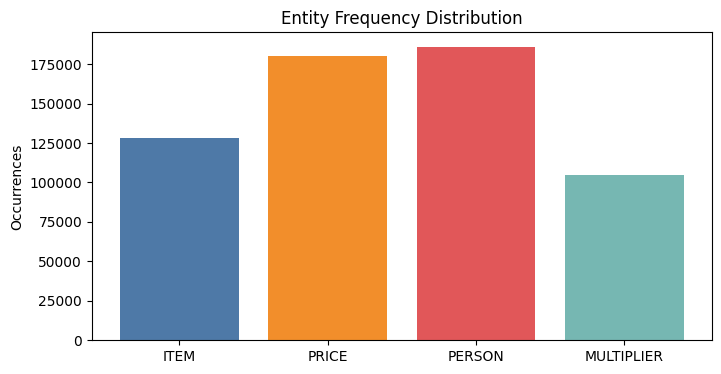

In [30]:
check_dataset_quality(df_train)

### Synthetic Dataset: Sequence Length Distribution

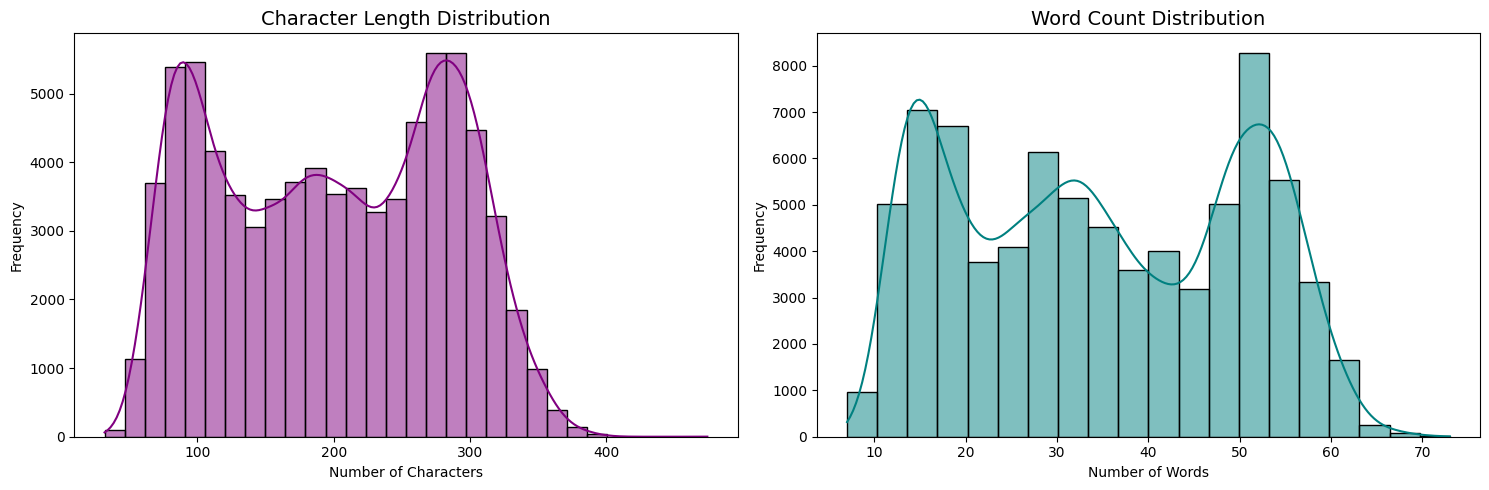

Max Word Count: 73
95th Percentile Word Count: 58


In [31]:
df_train['char_length'] = df_train['text'].apply(len)
df_train['word_count'] = df_train['text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Character Length
sns.histplot(df_train['char_length'], bins=30, kde=True, ax=axes[0], color='purple')
axes[0].set_title('Character Length Distribution', fontsize=14)
axes[0].set_xlabel('Number of Characters')
axes[0].set_ylabel('Frequency')

# Word Count
sns.histplot(df_train['word_count'], bins=20, kde=True, ax=axes[1], color='teal')
axes[1].set_title('Word Count Distribution', fontsize=14)
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"Max Word Count: {df_train['word_count'].max()}")
print(f"95th Percentile Word Count: {int(df_train['word_count'].quantile(0.95))}")

### Entity Length Distributions

C:\Users\ASUS\AppData\Local\Temp\ipykernel_29476\2259941115.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Entity Type", y="Length (Chars)", data=df_ents, palette="pastel")


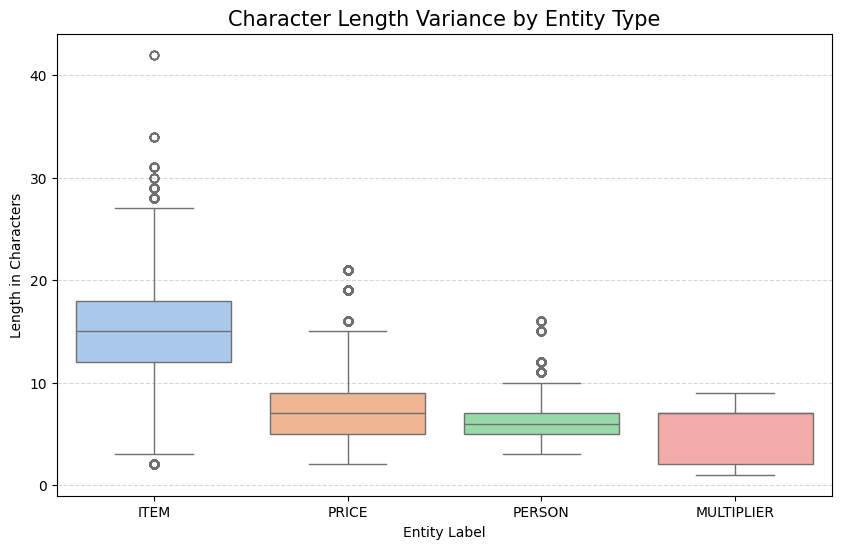

In [32]:
ent_data = []
for ents in df_train['entities']:
    for ent in ents:
        ent_type = ent.get('label', ent.get('entity'))
        ent_len = ent['end'] - ent['start']
        ent_data.append({"Entity Type": ent_type, "Length (Chars)": ent_len})

df_ents = pd.DataFrame(ent_data)

plt.figure(figsize=(10, 6))
sns.boxplot(x="Entity Type", y="Length (Chars)", data=df_ents, palette="pastel")
plt.title("Character Length Variance by Entity Type", fontsize=15)
plt.ylabel("Length in Characters")
plt.xlabel("Entity Label")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### Entity Positional Distribution

C:\Users\ASUS\AppData\Local\Temp\ipykernel_29476\1401720892.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Entity Type", y="Relative Position", data=df_pos, palette="muted", inner="quartile")


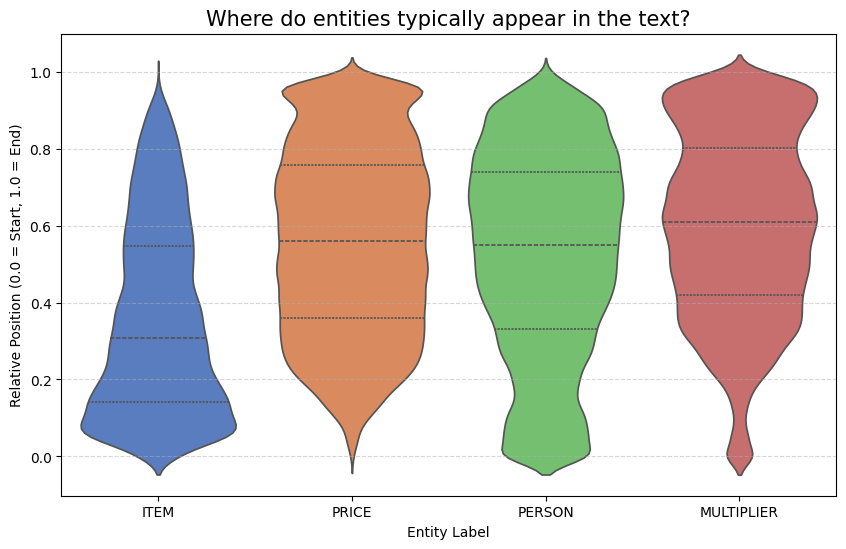

In [33]:
position_data = []
for idx, row in df_train.iterrows():
    text_len = max(len(row['text']), 1)
    for ent in row['entities']:
        ent_type = ent.get('label', ent.get('entity'))
        rel_pos = ent['start'] / text_len
        position_data.append({"Entity Type": ent_type, "Relative Position": rel_pos})

df_pos = pd.DataFrame(position_data)

plt.figure(figsize=(10, 6))
sns.violinplot(x="Entity Type", y="Relative Position", data=df_pos, palette="muted", inner="quartile")
plt.title("Where do entities typically appear in the text?", fontsize=15)
plt.ylabel("Relative Position (0.0 = Start, 1.0 = End)")
plt.xlabel("Entity Label")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### Number of Entities per Sentence

C:\Users\ASUS\AppData\Local\Temp\ipykernel_29476\1201046956.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=df_train['entity_count'], palette='magma')


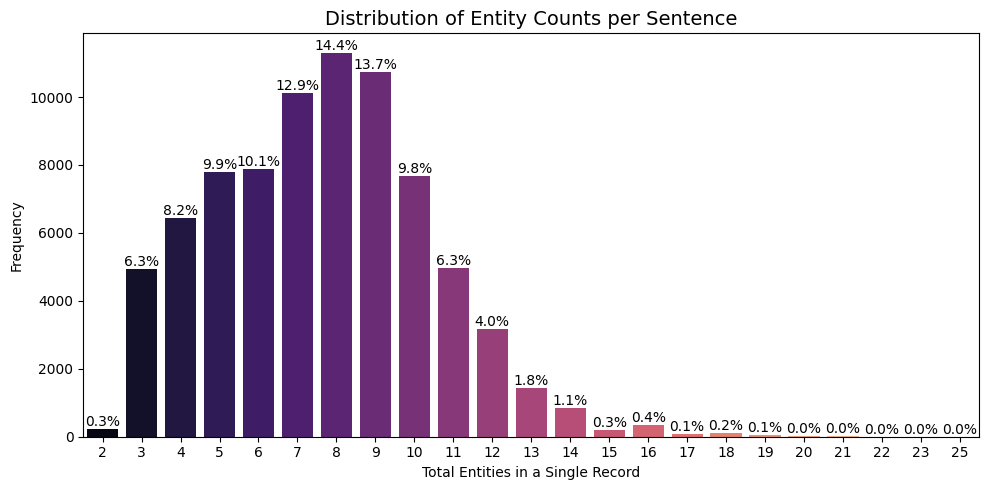

In [ ]:
df_train['entity_count'] = df_train['entities'].apply(len)

plt.figure(figsize=(10, 5))
ax = sns.countplot(x=df_train['entity_count'], palette='magma')
plt.title("Distribution of Entity Counts per Sentence", fontsize=14)
plt.xlabel("Total Entities in a Single Record")
plt.ylabel("Frequency")

total = len(df_train)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### Entity Co-occurrence Matrix


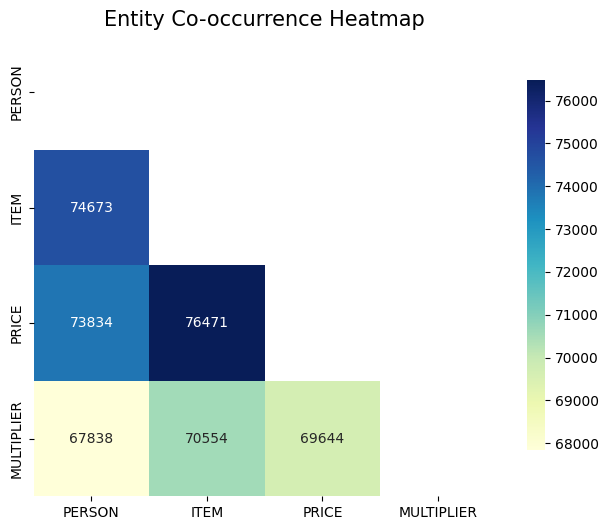

In [35]:
import numpy as np

entity_types = ["PERSON", "ITEM", "PRICE", "MULTIPLIER"]
co_mat = pd.DataFrame(0, index=entity_types, columns=entity_types)

for ents in df_train['entities']:
    present_ents = list(set([ent.get('label', ent.get('entity')) for ent in ents]))
    
    for i in range(len(present_ents)):
        for j in range(len(present_ents)):
            co_mat.loc[present_ents[i], present_ents[j]] += 1

mask = np.triu(np.ones_like(co_mat, dtype=bool))

plt.figure(figsize=(8, 6))
sns.heatmap(co_mat, mask=mask, annot=True, fmt="d", cmap="YlGnBu", 
            cbar_kws={"shrink": .8}, square=True)
plt.title("Entity Co-occurrence Heatmap", fontsize=15)
plt.show()

### Entity Sequence Transitions (Bigrams)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_29476\48716938.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


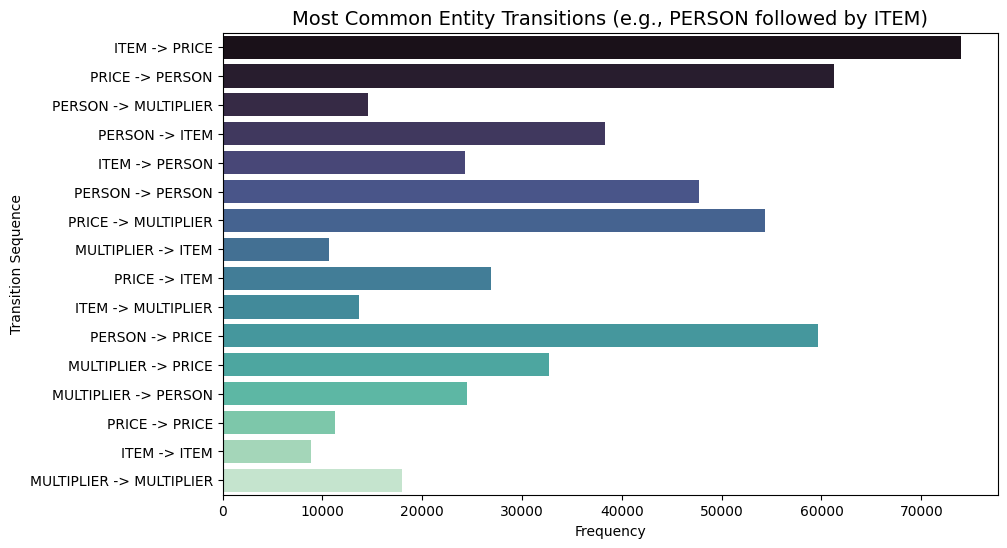

In [36]:
import networkx as nx

transitions = []
for ents in df_train['entities']:
    sorted_ents = sorted(ents, key=lambda x: x['start'])
    labels = [ent.get('label', ent.get('entity')) for ent in sorted_ents]
    
    for i in range(len(labels) - 1):
        transitions.append(f"{labels[i]} -> {labels[i+1]}")

transition_counts = Counter(transitions)

plt.figure(figsize=(10, 6))
sns.barplot(
    y=list(transition_counts.keys()), 
    x=list(transition_counts.values()), 
    palette="mako"
)
plt.title("Most Common Entity Transitions (e.g., PERSON followed by ITEM)", fontsize=14)
plt.xlabel("Frequency")
plt.ylabel("Transition Sequence")
plt.show()

### Entity vs Background (O-Tag) Density

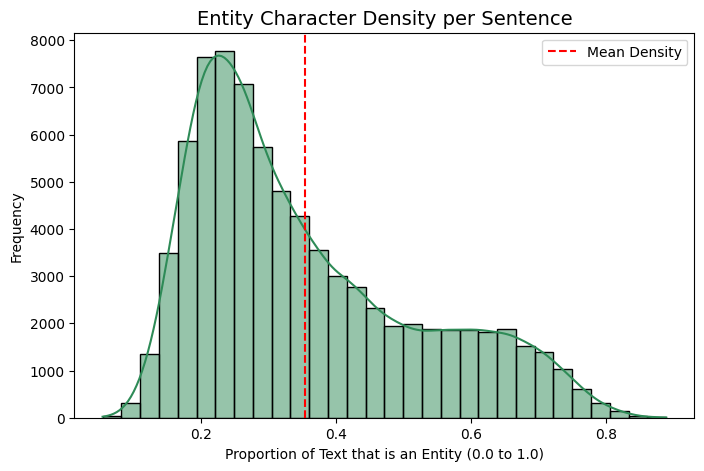

In [37]:
def calculate_entity_density(row):
    text_len = len(row['text'])
    if text_len == 0: return 0
    
    entity_chars = sum((ent['end'] - ent['start']) for ent in row['entities'])
    return entity_chars / text_len

df_train['entity_density'] = df_train.apply(calculate_entity_density, axis=1)

plt.figure(figsize=(8, 5))
sns.histplot(df_train['entity_density'], bins=30, kde=True, color='seagreen')
plt.title("Entity Character Density per Sentence", fontsize=14)
plt.xlabel("Proportion of Text that is an Entity (0.0 to 1.0)")
plt.ylabel("Frequency")
plt.axvline(df_train['entity_density'].mean(), color='red', linestyle='--', label='Mean Density')
plt.legend()
plt.show()

### Non-Entity Context Vocabulary

C:\Users\ASUS\AppData\Local\Temp\ipykernel_29476\2200079394.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[val for word, val in context_counts], y=[word for word, val in context_counts], palette="rocket")


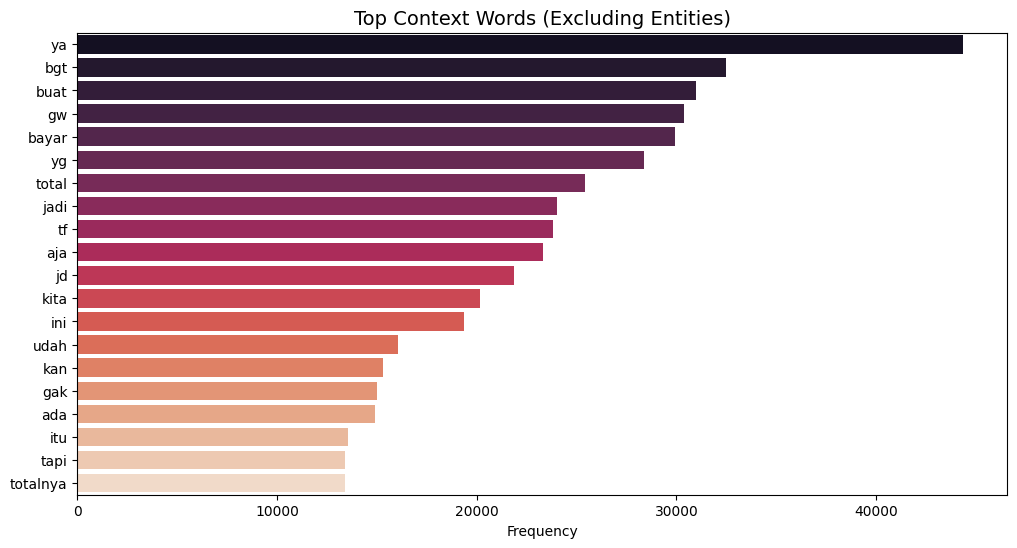

In [39]:
def extract_context_text(row):
    text = row['text']
    sorted_ents = sorted(row['entities'], key=lambda x: x['start'], reverse=True)
    
    for ent in sorted_ents:
        text = text[:ent['start']] + " " + text[ent['end']:]
    
    text = re.sub(r'[^\w\s]', '', text)
    return re.sub(r'\s+', ' ', text).strip()

df_train['context_text'] = df_train.apply(extract_context_text, axis=1)
all_context_words = " ".join(df_train['context_text']).lower().split()

context_counts = Counter(all_context_words).most_common(20)

plt.figure(figsize=(12, 6))
sns.barplot(x=[val for word, val in context_counts], y=[word for word, val in context_counts], palette="rocket")
plt.title("Top Context Words (Excluding Entities)", fontsize=14)
plt.xlabel("Frequency")
plt.show()

### Cross-Entity Distance (Span Gaps)

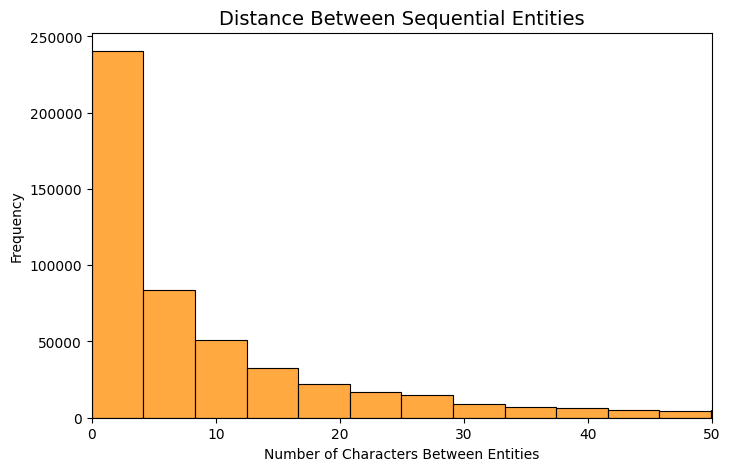

In [38]:
gaps = []
for ents in df_train['entities']:
    sorted_ents = sorted(ents, key=lambda x: x['start'])
    for i in range(len(sorted_ents) - 1):
        gap_length = sorted_ents[i+1]['start'] - sorted_ents[i]['end']
        gaps.append(gap_length)

plt.figure(figsize=(8, 5))
sns.histplot(gaps, bins=50, color='darkorange')
plt.title("Distance Between Sequential Entities", fontsize=14)
plt.xlabel("Number of Characters Between Entities")
plt.ylabel("Frequency")
plt.xlim(0, 50) 
plt.show()

 ### Price Format Distribution Sanity Check

C:\Users\ASUS\AppData\Local\Temp\ipykernel_29476\1253328419.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


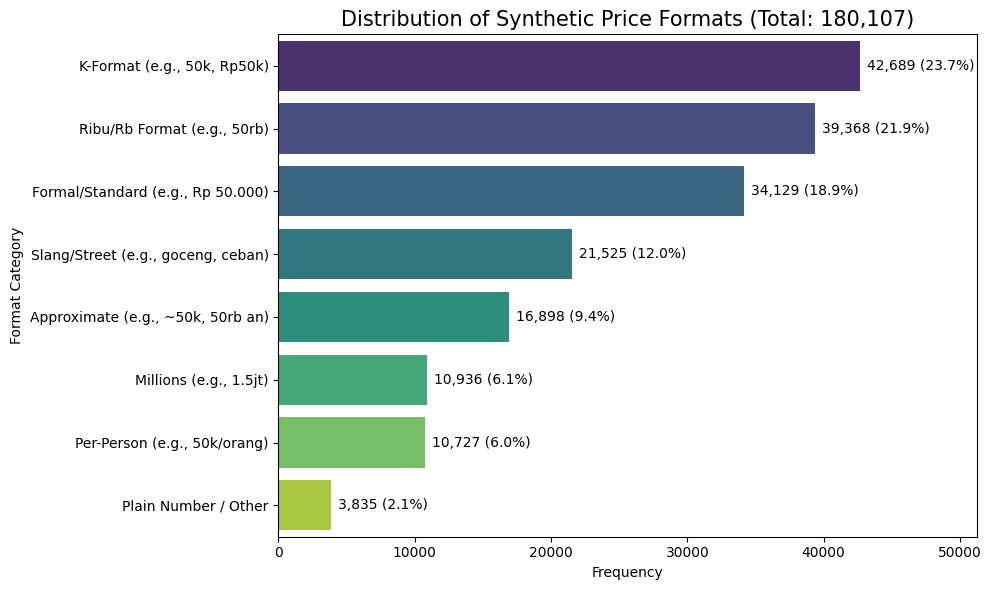

--- Regex Sanity Check (Random Samples) ---
[K-Format (e.g., 50k, Rp50k)]: ['RP20k', '73k', '44K']
[Ribu/Rb Format (e.g., 50rb)]: ['91rb', '19RB', '61rebu']
[Formal/Standard (e.g., Rp 50.000)]: ['Rp 488.000,-', '95.000', 'Rp52.000']
[Slang/Street (e.g., goceng, ceban)]: ['dua ceng', 'seceban', 'ceban']


In [40]:
price_entities = []
for ents in df_train['entities']:
    for ent in ents:
        label = ent.get('label', ent.get('entity'))
        if label == "PRICE":
            price_entities.append(ent['text'])

df_prices = pd.DataFrame({"raw_price": price_entities})

def categorize_price_format(text):
    text = str(text).lower().strip()
    
    if re.search(r'/(orang|kepala|org)|per\s*orang', text):
        return "Per-Person (e.g., 50k/orang)"
        
    if re.search(r'(gopek|ceng|ceban|noban|gocap|cepek|pek)', text) and not re.search(r'\d', text):
        return "Slang/Street (e.g., goceng, ceban)"
        
    if re.search(r'(jt|juta|j\b)', text):
        return "Millions (e.g., 1.5jt)"
        
    if re.search(r'(~|±|-an|\san\b)', text):
        return "Approximate (e.g., ~50k, 50rb an)"
        
    if re.search(r'k\b', text):
        return "K-Format (e.g., 50k, Rp50k)"
        
    if re.search(r'(rb|ribu|rebu)', text):
        return "Ribu/Rb Format (e.g., 50rb)"
        
    if re.search(r'(rp|idr|\.000)', text) or text.endswith(',-'):
        return "Formal/Standard (e.g., Rp 50.000)"
        
    return "Plain Number / Other"

df_prices['format_category'] = df_prices['raw_price'].apply(categorize_price_format)

format_counts = df_prices['format_category'].value_counts()
total_prices = len(df_prices)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    y=format_counts.index, 
    x=format_counts.values, 
    palette="viridis"
)

plt.title(f"Distribution of Synthetic Price Formats (Total: {total_prices:,})", fontsize=15)
plt.xlabel("Frequency")
plt.ylabel("Format Category")

for i, p in enumerate(ax.patches):
    count = int(p.get_width())
    percentage = f'{100 * count / total_prices:.1f}%'
    ax.annotate(
        f"{count:,} ({percentage})", 
        (count, p.get_y() + p.get_height() / 2), 
        ha='left', va='center', 
        xytext=(5, 0), textcoords='offset points',
        fontsize=10
    )

plt.xlim(0, format_counts.max() * 1.2)
plt.tight_layout()
plt.show()

print("--- Regex Sanity Check (Random Samples) ---")
for category in format_counts.index[:4]:  # Check top 4 categories
    samples = df_prices[df_prices['format_category'] == category]['raw_price'].sample(min(3, count)).tolist()
    print(f"[{category}]: {samples}")